# CC3104 – Aprendizaje por Refuerzo
## Laboratorio 1 — Task 3 — Implementación del evaluador de políticas (Entrega Final)

**Integrantes:**
- Sergio Orellana — 221122
- Rodrigo Mansilla — 22611
- Ricardo Chuy — 221007

---


### Objetivo

Implementar en Python, **desde cero** (sin librerías de RL como Gymnasium), un evaluador iterativo de políticas para un GridWorld 5x5 que represente la ciudad de drones, consistente con el diseño del MDP del Task 1.

Recuerden comentar el código explicando su relación con las fórmulas de las diapositivas (operador de Bellman).

---
### 1. Representación del MDP

Representen aquí el MDP completo: estados 𝒮, acciones 𝒜, función de transición 𝑝(𝑠′\|𝑠,𝑎) y función de recompensa 𝑟(𝑠,𝑎,𝑠′), consistentes con el diseño de la Tarea 1.

In [ ]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


class DroneGridWorldMDP:
    """MDP tabular para una misión de entrega y regreso en una cuadrícula 5x5."""

    def __init__(
        self,
        grid_size=5,
        base=(2, 2),
        delivery=(0, 4),
        max_battery=10,
    ):
        self.grid_size = grid_size
        self.base = base
        self.delivery = delivery
        self.max_battery = max_battery

        self.phases = ("en_camino", "regresando")
        self.actions = ("Norte", "Sur", "Este", "Oeste", "Esperar")

        self.terminal_success = ("COMPLETO",)
        self.terminal_failure = ("FALLA",)
        self.terminal_states = {
            self.terminal_success,
            self.terminal_failure,
        }

        self.states = [
            (row, col, phase, battery)
            for row in range(grid_size)
            for col in range(grid_size)
            for phase in self.phases
            for battery in range(1, max_battery + 1)
        ]
        self.states.extend(
            [self.terminal_success, self.terminal_failure]
        )

        self.action_delta = {
            "Norte": (-1, 0),
            "Sur": (1, 0),
            "Este": (0, 1),
            "Oeste": (0, -1),
            "Esperar": (0, 0),
        }

        self.left_of = {
            "Norte": "Oeste",
            "Sur": "Este",
            "Este": "Norte",
            "Oeste": "Sur",
        }
        self.right_of = {
            "Norte": "Este",
            "Sur": "Oeste",
            "Este": "Sur",
            "Oeste": "Norte",
        }

    def is_terminal(self, state):
        """Indica si el episodio terminó con éxito o con una falla."""
        return state in self.terminal_states

    def action_outcomes(self, action):
        """Devuelve las acciones realmente ejecutadas y sus probabilidades."""
        if action == "Esperar":
            return [("Esperar", 1.0)]

        return [
            (action, 0.8),
            (self.left_of[action], 0.1),
            (self.right_of[action], 0.1),
        ]

    def _apply_realized_action(self, state, realized_action):
        """Aplica un resultado concreto y calcula estado siguiente y recompensa."""
        row, col, phase, battery = state
        delta_row, delta_col = self.action_delta[realized_action]

        candidate = (
            row + delta_row,
            col + delta_col,
        )
        valid_move = (
            0 <= candidate[0] < self.grid_size
            and 0 <= candidate[1] < self.grid_size
        )

        if realized_action == "Esperar":
            next_position = (row, col)
            battery_cost = 1
        elif valid_move:
            next_position = candidate
            battery_cost = 1
        else:
            next_position = (row, col)
            battery_cost = 0

        next_battery = battery - battery_cost

        if phase == "regresando" and next_position == self.base:
            return self.terminal_success, 50.0

        if next_battery <= 0:
            return self.terminal_failure, -100.0

        if phase == "en_camino" and next_position == self.delivery:
            next_state = (
                next_position[0],
                next_position[1],
                "regresando",
                next_battery,
            )
            return next_state, 100.0

        next_state = (
            next_position[0],
            next_position[1],
            phase,
            next_battery,
        )
        return next_state, -1.0

    def transitions(self, state, action):
        """Implementa p(s', r | s, a)."""
        if self.is_terminal(state):
            return [(1.0, state, 0.0)]

        aggregated = defaultdict(float)

        for realized_action, probability in self.action_outcomes(action):
            next_state, reward = self._apply_realized_action(
                state,
                realized_action,
            )
            aggregated[(next_state, reward)] += probability

        return [
            (probability, next_state, reward)
            for (next_state, reward), probability in aggregated.items()
        ]

    def validate_transitions(self):
        """Verifica que las probabilidades de cada par (s, a) sumen 1."""
        errors = []

        for state in self.states:
            if self.is_terminal(state):
                continue

            for action in self.actions:
                total_probability = sum(
                    probability
                    for probability, _, _ in self.transitions(
                        state,
                        action,
                    )
                )

                if not np.isclose(total_probability, 1.0):
                    errors.append(
                        (state, action, total_probability)
                    )

        return errors


mdp = DroneGridWorldMDP()

print("Cantidad total de estados:", len(mdp.states))
print("Cantidad de acciones:", len(mdp.actions))
print("Errores en probabilidades:", mdp.validate_transitions())


Cantidad total de estados: 502
Cantidad de acciones: 5
Errores en probabilidades: []


In [ ]:
transition_examples = {
    "Movimiento desde el centro": mdp.transitions(
        (2, 2, "en_camino", 10),
        "Norte",
    ),
    "Intento de salir por el borde": mdp.transitions(
        (0, 2, "en_camino", 10),
        "Norte",
    ),
    "Llegada al punto de entrega": mdp.transitions(
        (0, 3, "en_camino", 10),
        "Este",
    ),
}

for description, outcomes in transition_examples.items():
    print(f"\n{description}")
    for probability, next_state, reward in outcomes:
        print(
            f"  p={probability:.1f} -> "
            f"s'={next_state}, r={reward:.1f}"
        )



Movimiento desde el centro
  p=0.8 -> s'=(1, 2, 'en_camino', 9), r=-1.0
  p=0.1 -> s'=(2, 1, 'en_camino', 9), r=-1.0
  p=0.1 -> s'=(2, 3, 'en_camino', 9), r=-1.0

Intento de salir por el borde
  p=0.8 -> s'=(0, 2, 'en_camino', 10), r=-1.0
  p=0.1 -> s'=(0, 1, 'en_camino', 9), r=-1.0
  p=0.1 -> s'=(0, 3, 'en_camino', 9), r=-1.0

Llegada al punto de entrega
  p=0.8 -> s'=(0, 4, 'regresando', 9), r=100.0
  p=0.1 -> s'=(0, 3, 'en_camino', 10), r=-1.0
  p=0.1 -> s'=(1, 3, 'en_camino', 9), r=-1.0


---
### 2. Evaluación iterativa de políticas

Implementen la evaluación iterativa de políticas mediante aplicación repetida del operador de Bellman:

$$V_{k+1}^{\pi}(s) = \sum_{a} \pi(a\mid s) \sum_{s'} p(s'\mid s,a)\,\big[r(s,a,s') + \gamma V_k^{\pi}(s')\big]$$

El criterio de convergencia debe ser configurable mediante un umbral 𝜃: el algoritmo termina cuando el cambio máximo en cualquier valor de estado entre dos iteraciones consecutivas es menor que 𝜃.

In [ ]:
def action_value(mdp, state, action, values, gamma):
    """Calcula q(s, a) a partir de un vector de valores V."""
    return sum(
        probability * (
            reward + gamma * values[next_state]
        )
        for probability, next_state, reward
        in mdp.transitions(state, action)
    )


def policy_evaluation(
    mdp,
    policy,
    gamma=0.95,
    theta=1e-8,
    max_iterations=10_000,
):
    """Evalúa una política mediante aplicaciones repetidas de Bellman."""
    values = {
        state: 0.0
        for state in mdp.states
    }

    for iteration in range(1, max_iterations + 1):
        new_values = values.copy()
        delta = 0.0

        for state in mdp.states:
            if mdp.is_terminal(state):
                new_values[state] = 0.0
                continue

            updated_value = 0.0

            for action, action_probability in policy[state].items():
                updated_value += (
                    action_probability
                    * action_value(
                        mdp,
                        state,
                        action,
                        values,
                        gamma,
                    )
                )

            new_values[state] = updated_value
            delta = max(
                delta,
                abs(updated_value - values[state]),
            )

        values = new_values

        if delta < theta:
            return values, iteration, delta

    raise RuntimeError(
        "La evaluación no convergió dentro del límite configurado."
    )


---
### 3. Definición de las tres políticas a evaluar

1. La política uniforme aleatoria.
2. Una política determinista fija definida por ustedes.
3. La política greedy derivada de los valores de la política anterior.

In [ ]:
def make_uniform_random_policy(mdp):
    probability = 1.0 / len(mdp.actions)

    return {
        state: {
            action: probability
            for action in mdp.actions
        }
        for state in mdp.states
        if not mdp.is_terminal(state)
    }


def manual_action(mdp, state):
    """Regla fija: movimiento vertical primero y horizontal después."""
    row, col, phase, _ = state

    if phase == "en_camino":
        target_row, target_col = mdp.delivery
    else:
        target_row, target_col = mdp.base

    if row > target_row:
        return "Norte"
    if row < target_row:
        return "Sur"
    if col < target_col:
        return "Este"
    if col > target_col:
        return "Oeste"

    return "Esperar"


def make_manual_policy(mdp):
    return {
        state: {
            manual_action(mdp, state): 1.0
        }
        for state in mdp.states
        if not mdp.is_terminal(state)
    }


def make_greedy_policy_from_values(
    mdp,
    values,
    gamma=0.95,
):
    """Construye una política determinista greedy a partir de V."""
    policy = {}
    q_values = {}

    for state in mdp.states:
        if mdp.is_terminal(state):
            continue

        state_action_values = {
            action: action_value(
                mdp,
                state,
                action,
                values,
                gamma,
            )
            for action in mdp.actions
        }

        best_value = max(state_action_values.values())
        best_action = next(
            action
            for action in mdp.actions
            if np.isclose(
                state_action_values[action],
                best_value,
            )
        )

        policy[state] = {
            best_action: 1.0
        }
        q_values[state] = state_action_values

    return policy, q_values


random_policy = make_uniform_random_policy(mdp)
manual_policy = make_manual_policy(mdp)


---
### 4. Evaluación y tablas de valores

Para cada política evaluada, produzcan: una tabla de valores 𝑉^π(𝑠) para todos los estados, y el número de iteraciones hasta convergencia.

In [ ]:
GAMMA = 0.95
THETA = 1e-8

random_values, random_iterations, random_delta = policy_evaluation(
    mdp,
    random_policy,
    gamma=GAMMA,
    theta=THETA,
)

manual_values, manual_iterations, manual_delta = policy_evaluation(
    mdp,
    manual_policy,
    gamma=GAMMA,
    theta=THETA,
)

greedy_policy, greedy_q_values = make_greedy_policy_from_values(
    mdp,
    random_values,
    gamma=GAMMA,
)

greedy_values, greedy_iterations, greedy_delta = policy_evaluation(
    mdp,
    greedy_policy,
    gamma=GAMMA,
    theta=THETA,
)

initial_state = (
    mdp.base[0],
    mdp.base[1],
    "en_camino",
    mdp.max_battery,
)

evaluation_summary = pd.DataFrame(
    [
        {
            "Política": "Uniforme aleatoria",
            "Iteraciones": random_iterations,
            "Delta final": random_delta,
            "V(base, en_camino, batería=10)": random_values[initial_state],
        },
        {
            "Política": "Determinista fija",
            "Iteraciones": manual_iterations,
            "Delta final": manual_delta,
            "V(base, en_camino, batería=10)": manual_values[initial_state],
        },
        {
            "Política": "Greedy derivada de aleatoria",
            "Iteraciones": greedy_iterations,
            "Delta final": greedy_delta,
            "V(base, en_camino, batería=10)": greedy_values[initial_state],
        },
    ]
)

display(evaluation_summary.round(6))


,Política,Iteraciones,Delta final,"V(base, en_camino, batería=10)"
0,Uniforme aleatoria,44,0.0,-62.075041
1,Determinista fija,25,0.0,79.022637
2,Greedy derivada de aleatoria,198,0.0,74.462058


In [9]:
def build_full_value_table(
    mdp,
    random_values,
    manual_values,
    greedy_values,
):
    """Construye una tabla con V(s) para todos los estados del MDP."""
    rows = []

    for state in mdp.states:
        if mdp.is_terminal(state):
            row = None
            col = None
            phase = state[0]
            battery = 0
        else:
            row, col, phase, battery = state

        rows.append(
            {
                "Estado": str(state),
                "Fila": row,
                "Columna": col,
                "Fase": phase,
                "Batería": battery,
                "V aleatoria": random_values[state],
                "V determinista": manual_values[state],
                "V greedy": greedy_values[state],
            }
        )

    return pd.DataFrame(rows)


full_value_table = build_full_value_table(
    mdp,
    random_values,
    manual_values,
    greedy_values,
)

print("Número de estados incluidos:", len(full_value_table))
display(full_value_table.round(4))

full_value_table.to_csv(
    "valores_completos_task3.csv",
    index=False,
)


Número de estados incluidos: 502


,Estado,Fila,Columna,Fase,Batería,V aleatoria,V determinista,V greedy
0,"(0, 0, 'en_camino', 1)",0.0,0.0,en_camino,1,-97.4194,-99.5580,-75.1724
1,"(0, 0, 'en_camino', 2)",0.0,0.0,en_camino,2,-92.1522,-95.1625,-63.6782
2,"(0, 0, 'en_camino', 3)",0.0,0.0,en_camino,3,-87.4617,-91.0537,-51.5976
3,"(0, 0, 'en_camino', 4)",0.0,0.0,en_camino,4,-83.2486,-87.1650,-45.0148
4,"(0, 0, 'en_camino', 5)",0.0,0.0,en_camino,5,-78.9526,-30.6206,-22.4628
...,...,...,...,...,...,...,...,...
497,"(4, 4, 'regresando', 8)",4.0,4.0,regresando,8,-56.7743,33.0847,16.0664
498,"(4, 4, 'regresando', 9)",4.0,4.0,regresando,9,-51.8373,33.1809,16.2159
499,"(4, 4, 'regresando', 10)",4.0,4.0,regresando,10,-47.3125,35.5134,17.4864
500,"('COMPLETO',)",NaN,NaN,COMPLETO,0,0.0000,0.0000,0.0000


In [10]:
def value_grid(
    mdp,
    values,
    phase="en_camino",
    battery=10,
):
    grid = np.zeros(
        (mdp.grid_size, mdp.grid_size),
        dtype=float,
    )

    for row in range(mdp.grid_size):
        for col in range(mdp.grid_size):
            state = (
                row,
                col,
                phase,
                battery,
            )
            grid[row, col] = values[state]

    return pd.DataFrame(
        grid,
        index=[
            f"Fila {row}"
            for row in range(mdp.grid_size)
        ],
        columns=[
            f"Columna {col}"
            for col in range(mdp.grid_size)
        ],
    )


print("Política uniforme aleatoria")
display(value_grid(mdp, random_values).round(2))

print("Política determinista fija")
display(value_grid(mdp, manual_values).round(2))

print("Política greedy derivada de la aleatoria")
display(value_grid(mdp, greedy_values).round(2))


Política uniforme aleatoria


,Columna 0,Columna 1,Columna 2,Columna 3,Columna 4
Fila 0,-60.39,-57.8,-45.88,-15.02,24.35
Fila 1,-63.16,-62.1,-55.08,-39.22,-15.02
Fila 2,-64.78,-65.1,-62.08,-55.08,-45.88
Fila 3,-64.90,-66.0,-65.10,-62.10,-57.80
Fila 4,-63.56,-64.9,-64.78,-63.16,-60.39


Política determinista fija


,Columna 0,Columna 1,Columna 2,Columna 3,Columna 4
Fila 0,77.13,90.40,114.81,126.99,131.52
Fila 1,43.19,78.35,91.72,115.95,126.99
Fila 2,32.69,39.46,79.02,92.68,114.91
Fila 3,-7.51,23.24,39.84,79.56,90.63
Fila 4,-27.96,-12.79,22.20,39.75,76.84


Política greedy derivada de la aleatoria


,Columna 0,Columna 1,Columna 2,Columna 3,Columna 4
Fila 0,46.90,84.39,101.39,111.85,115.41
Fila 1,1.88,74.28,86.19,102.36,111.85
Fila 2,-15.04,45.66,74.46,86.19,101.39
Fila 3,-22.09,-19.02,45.66,74.28,84.39
Fila 4,-23.48,-22.09,-15.04,1.88,46.90


---
### 5. Visualización

Para cada política evaluada, produzcan una visualización del grid con los valores codificados en color y las acciones de la política greedy superpuestas como flechas.

In [11]:
# TODO: graficar el grid 5x5 con V(s) en color y flechas de la politica (matplotlib)
ACTION_SYMBOLS = {
    "Norte": "↑",
    "Sur": "↓",
    "Este": "→",
    "Oeste": "←",
    "Esperar": "•",
}


def policy_symbol(policy, state):
    """Obtiene las acciones más probables de una política en un estado."""
    probabilities = policy[state]
    maximum_probability = max(probabilities.values())

    best_actions = [
        action
        for action, probability in probabilities.items()
        if np.isclose(
            probability,
            maximum_probability,
        )
    ]

    if len(best_actions) == len(ACTION_SYMBOLS):
        return "↕↔•"

    return "".join(
        ACTION_SYMBOLS[action]
        for action in best_actions
    )


def plot_policy_slice(
    mdp,
    values,
    policy,
    policy_name,
    phase,
    battery,
):
    """Dibuja un corte 5x5 con valores y acciones superpuestas."""
    grid = value_grid(
        mdp,
        values,
        phase=phase,
        battery=battery,
    ).to_numpy()

    plt.figure(figsize=(8, 7))
    plt.imshow(grid)
    plt.colorbar(label="Valor del estado V(s)")
    plt.title(
        f"{policy_name}\n"
        f"Fase: {phase}, batería: {battery}"
    )
    plt.xlabel("Columna")
    plt.ylabel("Fila")
    plt.xticks(range(mdp.grid_size))
    plt.yticks(range(mdp.grid_size))

    for row in range(mdp.grid_size):
        for col in range(mdp.grid_size):
            state = (
                row,
                col,
                phase,
                battery,
            )
            marker = ""

            if (row, col) == mdp.base:
                marker += " B"
            if (row, col) == mdp.delivery:
                marker += " D"

            annotation = (
                f"{grid[row, col]:.1f}\n"
                f"{policy_symbol(policy, state)}"
                f"{marker}"
            )

            plt.text(
                col,
                row,
                annotation,
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.show()


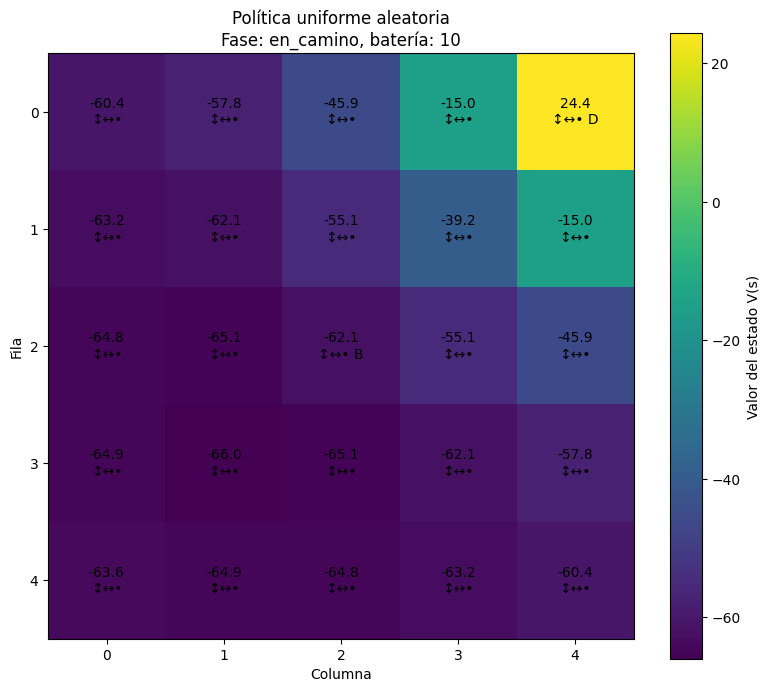

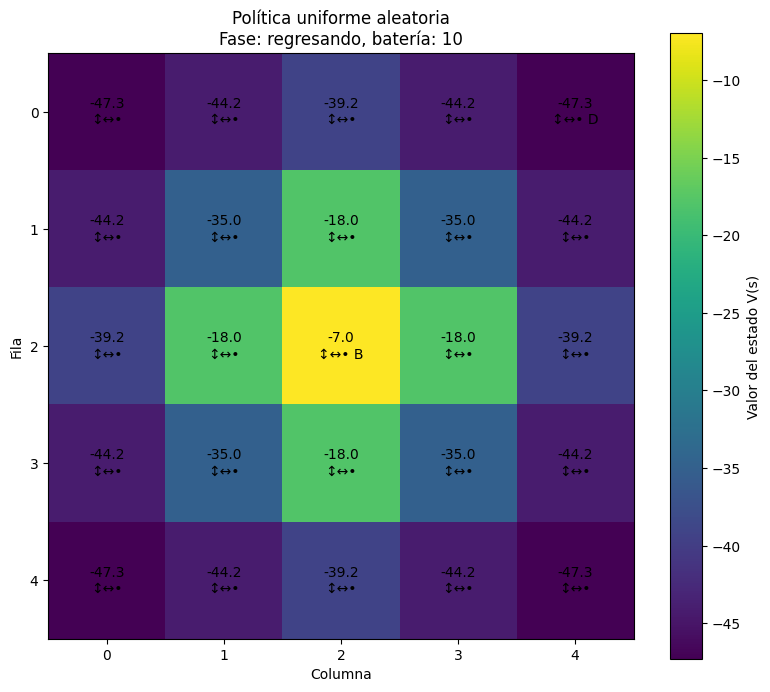

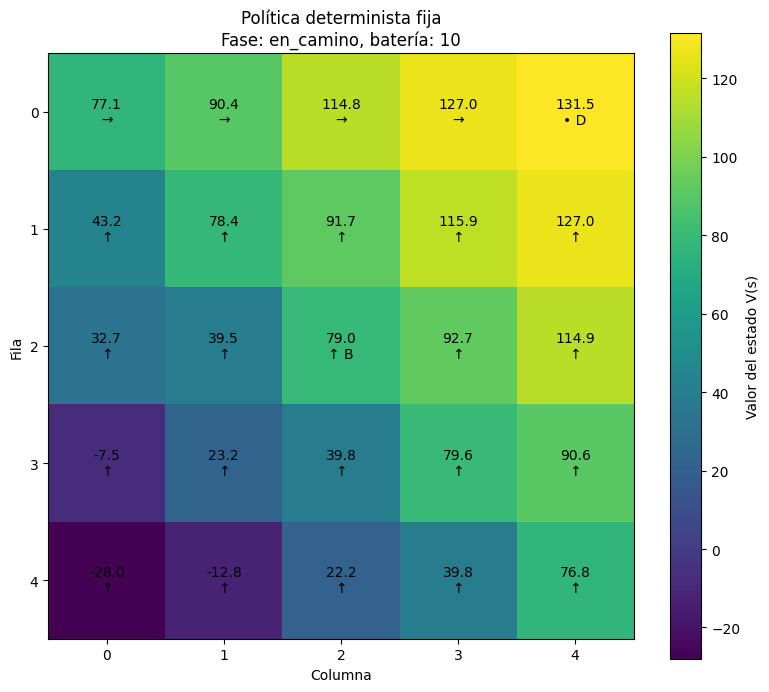

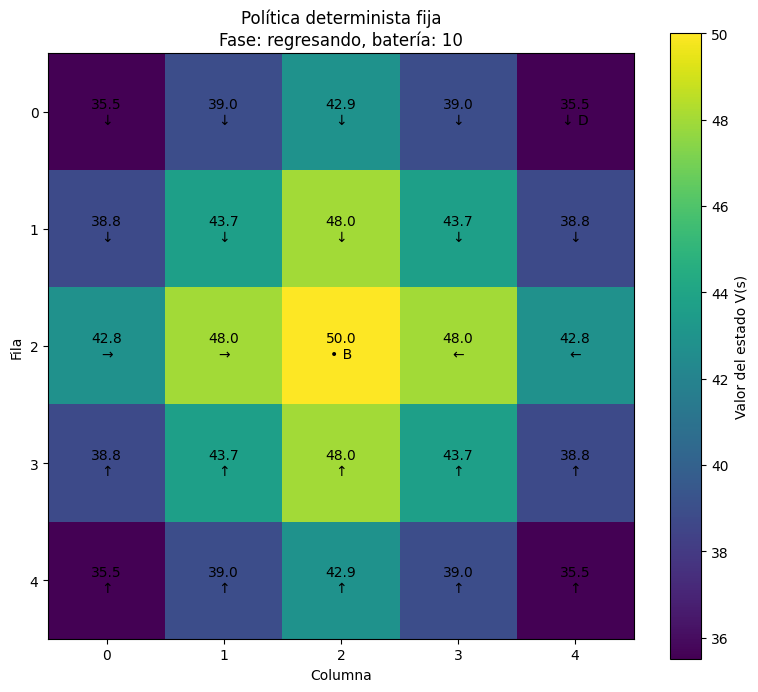

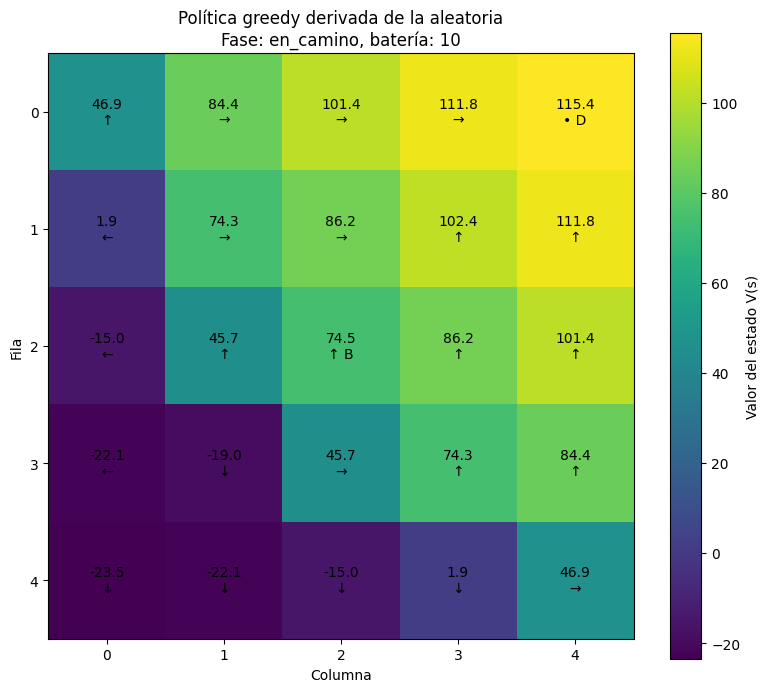

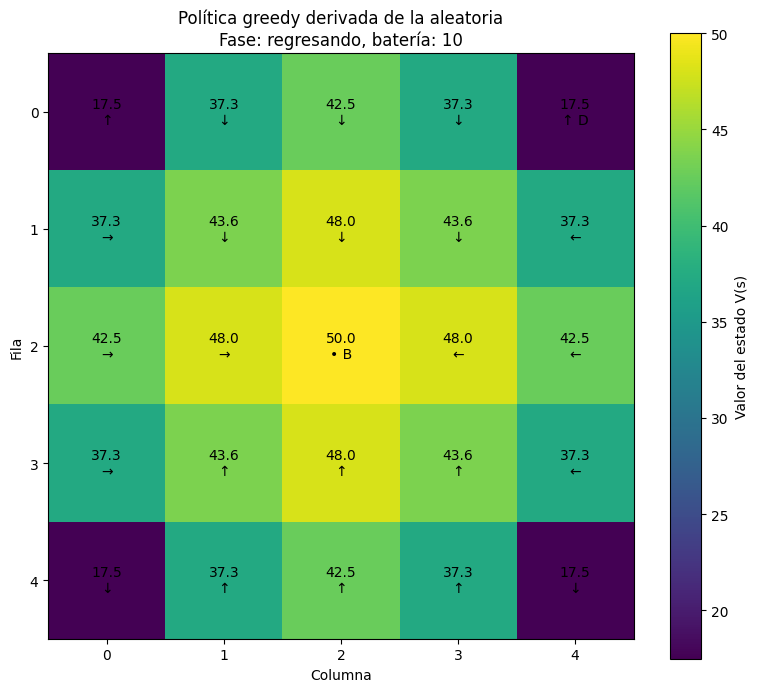

In [12]:
policies_and_values = [
    (
        "Política uniforme aleatoria",
        random_policy,
        random_values,
    ),
    (
        "Política determinista fija",
        manual_policy,
        manual_values,
    ),
    (
        "Política greedy derivada de la aleatoria",
        greedy_policy,
        greedy_values,
    ),
]

for policy_name, policy, values in policies_and_values:
    plot_policy_slice(
        mdp,
        values,
        policy,
        policy_name,
        phase="en_camino",
        battery=10,
    )

    plot_policy_slice(
        mdp,
        values,
        policy,
        policy_name,
        phase="regresando",
        battery=10,
    )
